In [1]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import pandas as pd
import numpy as np
import scipy
import time
from datetime import datetime, timedelta
import requests
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
import streamlit as st
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")
client = StockHistoricalDataClient(ALPACA_KEY,  ALPACA_SECRET)

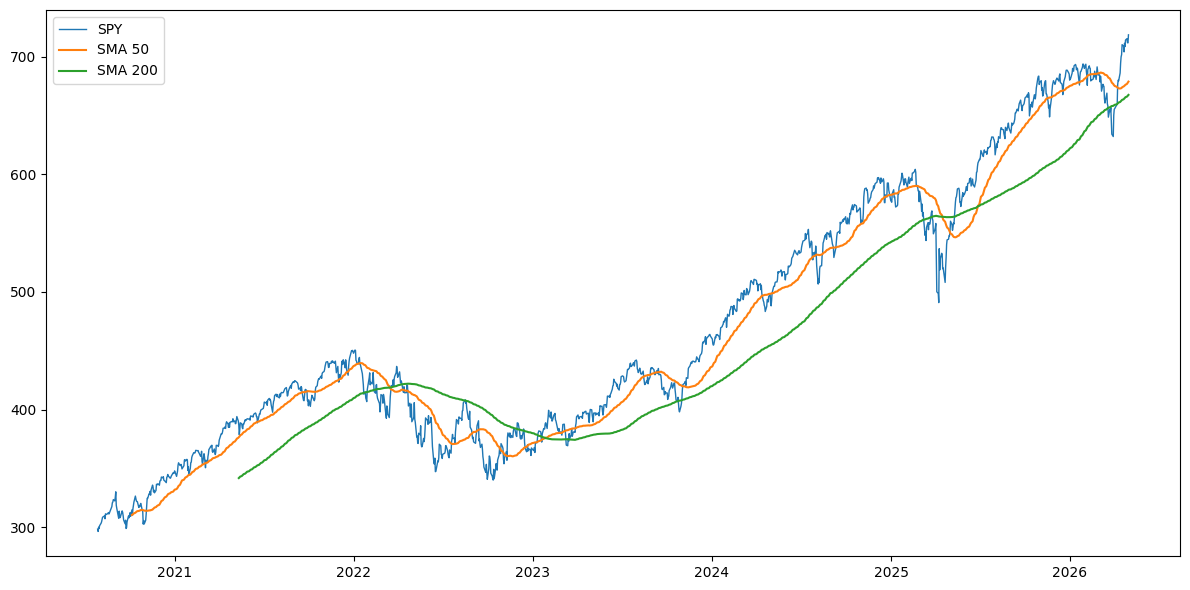

In [6]:
START_DATE = "2020-01-01"
END_DATE = datetime.now()
SYMBOL = "SPY"

params = StockBarsRequest(
    symbol_or_symbols=SYMBOL,
    timeframe=TimeFrame.Day,
    start=START_DATE,
    end=END_DATE,
    feed="iex",
    adjustment="all"
)

df = client.get_stock_bars(params).df
df = df.reset_index()
df = df[df["symbol"] == SYMBOL].set_index("timestamp")
df.index = df.index.tz_localize(None)

df["SMA_50"] = df["close"].rolling(window=50).mean()
df["SMA_200"] = df["close"].rolling(window=200).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["close"], label=SYMBOL, linewidth=1)
plt.plot(df.index, df["SMA_50"], label="SMA 50")
plt.plot(df.index, df["SMA_200"], label="SMA 200")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
df["signal"] = np.where(df["SMA_50"] > df["SMA_200"], 1, -1)

df["position"] = df["signal"].shift(1)

df["market_return"] = df["close"].pct_change()
df["strategy_return"] = df["market_return"] * df["position"]

In [26]:
df["buy_signal"] = np.where(
    (df["position"] == 1) & (df["position"].shift(1) == 0),
    df["close"], np.nan
)
df["sell_signal"] = np.where(
    (df["position"] == 0) & (df["position"].shift(1) == 1),
    df["close"], np.nan
)

Total Return:  16.12%
Sharpe Ratio:  0.17
Max Drawdown:  -27.04%


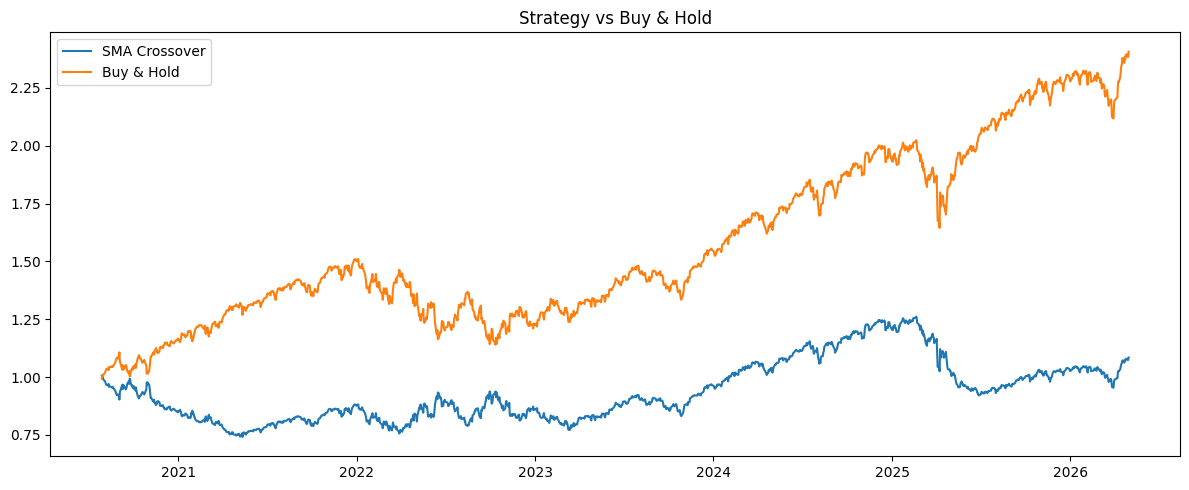

In [27]:
trading_days = 252

total_return = df["strategy_return"].sum()
sharpe = (df["strategy_return"].mean() / df["strategy_return"].std()) * np.sqrt(trading_days)

equity_curve = (1 + df["strategy_return"]).cumprod()
max_drawdown = ((equity_curve - equity_curve.cummax()) / equity_curve.cummax()).min()

print(f"Total Return:  {total_return:.2%}")
print(f"Sharpe Ratio:  {sharpe:.2f}")
print(f"Max Drawdown:  {max_drawdown:.2%}")

df["equity_curve"] = (1 + df["strategy_return"]).cumprod()
df["buy_hold"] = (1 + df["market_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["equity_curve"], label="SMA Crossover")
plt.plot(df.index, df["buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Strategy vs Buy & Hold")
plt.tight_layout()
plt.show()